## Japan Cherry Blossom Forecast ##
Below, is a preliminary exploratory analysis of Japanese Cherry Blossom Forecast for 2024. The purpose of this demonstration, is the learn how to connect a Git-Hub repo to a Jupyter Notebook and do some basic exploratory analysis with the data. The business question is associated with the Japan branch on an international tourism company that arranges tours and specialized offerings. By far, the most popular offering is a tour for Cherry Blossom season. They have recently processed and translated 2024 cherry blossom forecast data from NHK and are hoping to utilize this information in selecting the order and location of potential itinerary offerings for tour groups based upon when the cherry blossoms are likely to peak in a given area, along with the temperature and precipitation forecast for an ideal experience.

Step #1: We begin by importing the relevant libraries:

In [25]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from urllib.request import urlopen
import ssl
import seaborn as sns
import plotly.express as px
from datetime import datetime
import plotly.figure_factory as ff
import kaleido
import plotly
import warnings
warnings.filterwarnings('ignore')

In [26]:
#Let's begin by downloading the "Cherry_Blossom_Forecasts.csv" file from the GitHub repository using the urlopen function.

ssl_context = ssl._create_unverified_context()
url1 = "https://raw.githubusercontent.com/homdch/Japan-Cherry-Blossom-Forecast/refs/heads/main/Cherry_Blossom_Forecasts.csv"

# Pass the opened handle directly to read_csv
with urlopen(url1, context=ssl_context) as response:
    df1 = pd.read_csv(response)

In [27]:
#Next, let's do the same for the "Cherry_Blossom_Places.csv" file.

ssl_context = ssl._create_unverified_context()
url2 = "https://raw.githubusercontent.com/homdch/Japan-Cherry-Blossom-Forecast/refs/heads/main/Cherry_Blossom_Places.csv"

# Pass the opened handle directly to read_csv
with urlopen(url2, context=ssl_context) as response:
    df2 = pd.read_csv(response)

Step #2: Let's continue by conducting an exploratory analysis.

In [28]:
print("Cherry Blossom Forecasts:")
print(df1.head(5))
print("Cherry Blossom Places:")
print(df2.head(5))

Cherry Blossom Forecasts:
   place_code    date mankai_date kaika_date  meter      ft  tavg  tmin  tmax  \
0     1370053  2/1/24     5/12/24     5/7/24     12  3.6576  -7.8 -11.4  -5.3   
1     1370022  2/1/24      5/3/24    4/29/24     12  3.6576  -4.2  -7.6   0.5   
2     1370024  2/1/24      5/9/24     5/4/24     10  3.0480  -4.2  -7.6   0.5   
3     1370028  2/1/24     5/10/24     5/4/24     13  3.9624  -5.6  -6.8  -4.5   
4     1370029  2/1/24      5/9/24     5/6/24     13  3.9624   NaN   NaN   NaN   

   tavg_f  tmin_f  tmax_f  prcp    pcp_in  
0   17.96   11.48   22.46   4.1  0.161417  
1   24.44   18.32   32.90   0.3  0.011811  
2   24.44   18.32   32.90   0.3  0.011811  
3   21.92   19.76   23.90   0.0  0.000000  
4   32.00   32.00   32.00   NaN  0.000000  
Cherry Blossom Places:
        prefecture                         spot_name        lat         lon  \
0  Hokkaido Island       Higashimei Park, Bibai City  43.340985  141.895581   
1  Hokkaido Island                    Gory

#### Context: ####

Date: Pertains the the date at which the estimate for cherry blossom season prediction was recorded for a particular location.

Kaika Dates: Pertains to the sart of flowering for cherry blossom season.

Mankai Dates: Ths marks full bloom for cherry blossoms.

Cherry blossom peak full bloom (mankai) typically lasts for about 5-7 days (up to a week) before the petals begin
to fall off. for the purpose of estimating the cherry blossom end date, for the purpose of this analysis, we will assume that the end of
blossoming for a particular area occurs roughly a week after the Mankai dates. We will add a column for the estimated end date to the data frame
for Cherry Blossoms Forecasts.


In [29]:

#Reformats the date data#
df1['date'] = pd.to_datetime(df1['date'])
df1['kaika_date'] = pd.to_datetime(df1['kaika_date'])
df1['mankai_date'] = pd.to_datetime(df1['mankai_date'])
#Calculates the estimated end date for a particular area #
df1['estimated_end_date'] = df1['mankai_date'] + pd.Timedelta(weeks=1)
df1.head(5)

,place_code,date,mankai_date,kaika_date,meter,ft,tavg,tmin,tmax,tavg_f,tmin_f,tmax_f,prcp,pcp_in,estimated_end_date
0,1370053,2024-02-01,2024-05-12,2024-05-07,12,3.6576,-7.8,-11.4,-5.3,17.96,11.48,22.46,4.1,0.161417,2024-05-19
1,1370022,2024-02-01,2024-05-03,2024-04-29,12,3.6576,-4.2,-7.6,0.5,24.44,18.32,32.90,0.3,0.011811,2024-05-10
2,1370024,2024-02-01,2024-05-09,2024-05-04,10,3.0480,-4.2,-7.6,0.5,24.44,18.32,32.90,0.3,0.011811,2024-05-16
3,1370028,2024-02-01,2024-05-10,2024-05-04,13,3.9624,-5.6,-6.8,-4.5,21.92,19.76,23.90,0.0,0.000000,2024-05-17
4,1370029,2024-02-01,2024-05-09,2024-05-06,13,3.9624,NaN,NaN,NaN,32.00,32.00,32.00,NaN,0.000000,2024-05-16


Next, let's calculate the estimated number of days of cherry blossom season this will be accomplished by subtracting the kaika_date
from the end date.

In [30]:
#we can also rearrange the columns to have it make more sense.#
df1['duration'] = df1['estimated_end_date'] - df1['kaika_date']
desired_order = ['place_code', 'date', 'kaika_date', 'mankai_date', 'estimated_end_date', 'duration',
                 'meter','ft','tavg','tmin','tmax','tavg_f','tmin_f','tmax_f','prcp','pcp_in']
df1 = df1.reindex(columns=desired_order)
df1.head(5)

,place_code,date,kaika_date,mankai_date,estimated_end_date,duration,meter,ft,tavg,tmin,tmax,tavg_f,tmin_f,tmax_f,prcp,pcp_in
0,1370053,2024-02-01,2024-05-07,2024-05-12,2024-05-19,12 days,12,3.6576,-7.8,-11.4,-5.3,17.96,11.48,22.46,4.1,0.161417
1,1370022,2024-02-01,2024-04-29,2024-05-03,2024-05-10,11 days,12,3.6576,-4.2,-7.6,0.5,24.44,18.32,32.90,0.3,0.011811
2,1370024,2024-02-01,2024-05-04,2024-05-09,2024-05-16,12 days,10,3.0480,-4.2,-7.6,0.5,24.44,18.32,32.90,0.3,0.011811
3,1370028,2024-02-01,2024-05-04,2024-05-10,2024-05-17,13 days,13,3.9624,-5.6,-6.8,-4.5,21.92,19.76,23.90,0.0,0.000000
4,1370029,2024-02-01,2024-05-06,2024-05-09,2024-05-16,10 days,13,3.9624,NaN,NaN,NaN,32.00,32.00,32.00,NaN,0.000000


Now that we have calculated the necessary inforamtion, we can now create some data visualizations for a preliminary analysis. We can begin by incorporating the geographic data.
This information can be used to create a map plot with the kaika and mankai dates to determine when cherry blossom season is likely to begin and peak for each site.

In [31]:
# We can begin by merging the two dataframes together on place_code, in a dataframe called df_merged. This merged data can form the basis of our mapping information.#

df_merged = df1.merge(df2, left_on='place_code', right_on='code')
del df_merged['code']

df_merged.head()

,place_code,date,kaika_date,mankai_date,estimated_end_date,duration,meter,ft,tavg,tmin,tmax,tavg_f,tmin_f,tmax_f,prcp,pcp_in,prefecture,spot_name,lat,lon
0,1370053,2024-02-01,2024-05-07,2024-05-12,2024-05-19,12 days,12,3.6576,-7.8,-11.4,-5.3,17.96,11.48,22.46,4.1,0.161417,Hokkaido Island,"Higashimei Park, Bibai City",43.340985,141.895581
1,1370022,2024-02-01,2024-04-29,2024-05-03,2024-05-10,11 days,12,3.6576,-4.2,-7.6,0.5,24.44,18.32,32.90,0.3,0.011811,Hokkaido Island,Goryokaku Park,41.797090,140.755737
2,1370024,2024-02-01,2024-05-04,2024-05-09,2024-05-16,12 days,10,3.0480,-4.2,-7.6,0.5,24.44,18.32,32.90,0.3,0.011811,Hokkaido Island,Aobagaoka Park,42.102654,140.575608
3,1370028,2024-02-01,2024-05-04,2024-05-10,2024-05-17,13 days,13,3.9624,-5.6,-6.8,-4.5,21.92,19.76,23.90,0.0,0.000000,Hokkaido Island,Uju Zenkoji Temple Natural Park,42.522993,140.780671
4,1370029,2024-02-01,2024-05-06,2024-05-09,2024-05-16,10 days,13,3.9624,NaN,NaN,NaN,32.00,32.00,32.00,NaN,0.000000,Hokkaido Island,Nijukken Road Cherry Blossom Row,42.403905,142.452358


In [32]:
#NOTE: In order to get the map visualization to work properly, the kaleido library must be installed. To install, open up the anaconda terminal and run the
# following commapnd: python3 -m pip install kaleido==0.4.2 or !python3 -m pip install plotly==5.24.1 kaleido==0.2.1 and then re-run the code again.#
def df_for_map(date='last'):
    if date == 'last':
        df_map = df_merged[df_merged['date'] == df_merged['date'].max()].copy()
    else:
        df_map = df_merged[df_merged['date'] == date].copy()

    # Convert to datetime first
    df_map['mankai_date'] = pd.to_datetime(df_map['mankai_date'])
    df_map['kaika_date'] = pd.to_datetime(df_map['kaika_date'])

    # Calculate days from today
    df_map['mankai_days'] = (datetime.now() - df_map['mankai_date']).dt.days
    df_map['kaika_days'] = (datetime.now() - df_map['kaika_date']).dt.days

    # Convert back to string for hover display
    df_map['mankai_date'] = df_map['mankai_date'].dt.strftime('%Y-%m-%d')
    df_map['kaika_date'] = df_map['kaika_date'].dt.strftime('%Y-%m-%d')

    return df_map


# ── Plotting ──────────────────────────────────────────────────────
METRIC = 'meter'
SAVE_IMG = True

df_map = df_for_map()

# scatter_mapbox → scatter_map
fig = px.scatter_map(
    df_map,
    lat="lat",
    lon="lon",
    color=METRIC,
    hover_name="spot_name",
    hover_data=["mankai_date", "kaika_date", "prefecture"],
    zoom=4,
    center={'lat': 38, 'lon': 138},
    height=700,
    map_style= "carto-darkmatter",          
    color_continuous_scale="Pinkyl",      
    range_color=[df_map[METRIC].min(), df_map[METRIC].max()]
)

fig.update_layout(
    title=dict(
        text="🌸 Sakura Bloom Locations in Japan",  # ← title text
        x=0.5,               # center the title
        xanchor='center',
        font=dict(
            size=20,
            color='black',
            family='Arial'
        )
    ),
    margin={"r":0,"t":50,"l":0,"b":0}  # ← increase top margin to make room for title
)

if SAVE_IMG:
    fig.write_image("sakura.png", format='png')
fig.show()

The most popular route for tourists in Japan is Tokyo, Osaka, and Kyoto. Most forecasts for cherry blossom season in Tokyo are roughly around the last week of March.
The same is typically true of Kyoto and Osaka; however Cherry Blossom season tends to start later in March than in Tokyo, but continues a little bit into the first week of April.
For optimal cherry blossom viewing at the major cities, it is recommended that visitors travel during the last week of March and durign the first week of April, preferably starting in Tokyo and then continuing their trip to Osaka or Kyoto. For earlier cherry blossom viewing, check out Kyushu or for later visits, check out northern Honshu and Hokkaido. Now that the map visual establishes the optimal dates for travel itineraries, we should now use the data to determine the optimal length of stay for the trip.


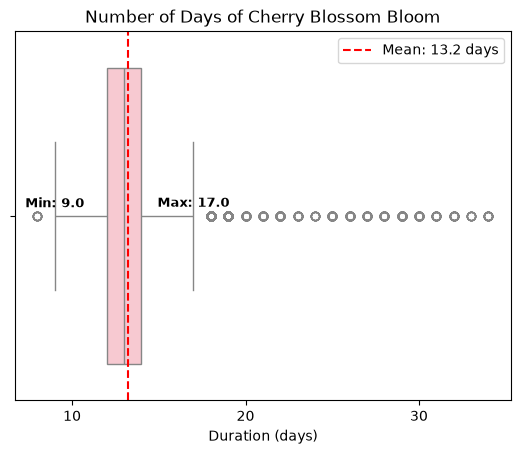

In [33]:
# Convert to numeric days first (if not done already)
df1['duration_days'] = df1['duration'].dt.days

# Calculate statistics
mean_val = df1["duration_days"].mean()
q1 = df1["duration_days"].quantile(0.25)
q3 = df1["duration_days"].quantile(0.75)
iqr = q3 - q1
lower_whisker = max(df1["duration_days"].min(), q1 - 1.5 * iqr)
upper_whisker = min(df1["duration_days"].max(), q3 + 1.5 * iqr)

# Create a horizontal boxplot
sns.boxplot(x=df1["duration_days"], color="#FFC1CC")

# Add mean line
plt.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f} days')

# Label lower whisker
plt.text(lower_whisker, 0.55, f'Min: {lower_whisker:.1f}',
    color='black', fontsize=9, fontweight='bold',
    ha='center', va='top',
    transform=plt.gca().get_xaxis_transform())

# Label upper whisker
plt.text(upper_whisker, 0.55, f'Max: {upper_whisker:.1f}',
    color='black', fontsize=9, fontweight='bold',
    ha='center', va='top',
    transform=plt.gca().get_xaxis_transform())

# Add titles and labels
plt.title("Number of Days of Cherry Blossom Bloom")
plt.xlabel("Duration (days)")

# Scale x-axis ticks by 10
plt.xticks(np.arange(
    round(df1["duration_days"].min(), -1),
    round(df1["duration_days"].max(), -1) + 10,
    10
))
plt.legend()
plt.show()

In [36]:
df1.head()

,place_code,date,kaika_date,mankai_date,estimated_end_date,duration,meter,ft,tavg,tmin,tmax,tavg_f,tmin_f,tmax_f,prcp,pcp_in,duration_days
0,1370053,2024-02-01,2024-05-07,2024-05-12,2024-05-19,12 days,12,3.6576,-7.8,-11.4,-5.3,17.96,11.48,22.46,4.1,0.161417,12
1,1370022,2024-02-01,2024-04-29,2024-05-03,2024-05-10,11 days,12,3.6576,-4.2,-7.6,0.5,24.44,18.32,32.90,0.3,0.011811,11
2,1370024,2024-02-01,2024-05-04,2024-05-09,2024-05-16,12 days,10,3.0480,-4.2,-7.6,0.5,24.44,18.32,32.90,0.3,0.011811,12
3,1370028,2024-02-01,2024-05-04,2024-05-10,2024-05-17,13 days,13,3.9624,-5.6,-6.8,-4.5,21.92,19.76,23.90,0.0,0.000000,13
4,1370029,2024-02-01,2024-05-06,2024-05-09,2024-05-16,10 days,13,3.9624,NaN,NaN,NaN,32.00,32.00,32.00,NaN,0.000000,10


On average, Cherry Blossom season seems to last only 13 days. If a visitor is lucky, they might be able to have a longer window. However,
it could also be a shorter window. It is recommended that they air on the side of caution and plan their trip in advance to begin nore more
than 1 week after the Kaika date for chose locations for optimization of viewing. As Cherry Blossom Season typically lasts 13 days, this time span should correspond with the ideal length of stay. However, a shorter stay of about 9 days could still be sufficient for viewing highlights or a longer stay for a more extensive itinerary.
